In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

pd.set_option("display.max_columns", None)

print("Libraries Loaded Successfully!")

Libraries Loaded Successfully!


In [2]:
# Clean NAV history
nav = pd.read_csv("../Data/Processed/clean_nav.csv")

# Fund Master
funds = pd.read_csv("../Data/Raw/01_fund_master.csv")

# Transactions
transactions = pd.read_csv("../Data/Processed/clean_transactions.csv")

# Portfolio Holdings
portfolio = pd.read_csv("../Data/Raw/09_portfolio_holdings.csv")

print("NAV:", nav.shape)
print("Funds:", funds.shape)
print("Transactions:", transactions.shape)
print("Portfolio:", portfolio.shape)

NAV: (46000, 3)
Funds: (40, 15)
Transactions: (32778, 13)
Portfolio: (322, 8)


In [3]:
print(nav.columns)

print("\n-----------------\n")

print(transactions.columns)

print("\n-----------------\n")

print(portfolio.columns)

Index(['amfi_code', 'date', 'nav'], dtype='str')

-----------------

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

-----------------

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')


In [6]:
nav.columns

Index(['amfi_code', 'date', 'nav'], dtype='str')

In [7]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [8]:
portfolio.columns

Index(['amfi_code', 'stock_symbol', 'stock_name', 'sector', 'weight_pct',
       'market_value_cr', 'current_price_inr', 'portfolio_date'],
      dtype='str')

In [9]:
# Convert date column to datetime
nav["date"] = pd.to_datetime(nav["date"])

# Sort values
nav = nav.sort_values(["amfi_code", "date"])

# Daily returns
nav["daily_return"] = nav.groupby("amfi_code")["nav"].pct_change()

nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


In [10]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    if len(returns) == 0:
        continue

    # Historical VaR (95%)
    var95 = np.percentile(returns, 5)

    # Conditional VaR
    cvar95 = returns[returns <= var95].mean()

    var_results.append({
        "amfi_code": fund,
        "VaR_95": var95,
        "CVaR_95": cvar95
    })

var_df = pd.DataFrame(var_results)

var_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_df = var_df.merge(
    funds[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

var_df = var_df[
    [
        "amfi_code",
        "scheme_name",
        "VaR_95",
        "CVaR_95"
    ]
]

var_df.head()

,amfi_code,scheme_name,VaR_95,CVaR_95
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,-0.014364,-0.018060
1,100025,HDFC Short Term Debt Fund - Regular - Growth,-0.003793,-0.004994
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
3,101206,ABSL Frontline Equity Fund - Regular - Growth,-0.013282,-0.017439
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459


In [12]:
var_df = var_df.sort_values("VaR_95")

var_df.head(10)

,amfi_code,scheme_name,VaR_95,CVaR_95
22,119599,SBI Small Cap Fund - Direct Plan - Growth,-0.026859,-0.032384
17,119095,Axis Small Cap Fund - Regular - Growth,-0.026188,-0.031667
4,101207,ABSL Small Cap Fund - Regular - Growth,-0.026021,-0.032459
11,118634,Nippon India Small Cap Fund - Regular - Growth,-0.025438,-0.032304
21,119598,SBI Small Cap Fund - Regular Plan - Growth,-0.024507,-0.030595
39,149324,DSP Small Cap Fund - Regular - Growth,-0.023483,-0.031036
7,102886,UTI Mid Cap Fund - Regular - Growth,-0.019220,-0.023251
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,-0.019034,-0.023456
25,120505,ICICI Pru Midcap Fund - Regular - Growth,-0.018892,-0.024342
16,119094,Axis Midcap Fund - Regular - Growth,-0.018480,-0.024260


In [13]:
var_df.to_csv(
    "../Reports/var_cvar_report.csv",
    index=False
)

print("✅ var_cvar_report.csv saved successfully!")

✅ var_cvar_report.csv saved successfully!


In [14]:
# First 5 AMFI Codes
selected_funds = nav["amfi_code"].unique()[:5]

selected_funds

array([100016, 100025, 100033, 101206, 101207])

In [15]:
rolling_df = []

for fund in selected_funds:

    temp = nav[nav["amfi_code"] == fund].copy()

    temp["rolling_sharpe"] = (
        temp["daily_return"]
        .rolling(90)
        .mean()
        /
        temp["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    rolling_df.append(temp)

rolling_df = pd.concat(rolling_df)

rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe
0,100016,2022-01-03,520.4608,NaN,NaN
1,100016,2022-01-04,515.0971,-0.010306,NaN
2,100016,2022-01-05,521.7239,0.012865,NaN
3,100016,2022-01-06,515.7880,-0.011377,NaN
4,100016,2022-01-07,515.1639,-0.001210,NaN


In [16]:
rolling_df = rolling_df.merge(
    funds[["amfi_code","scheme_name"]],
    on="amfi_code",
    how="left"
)

rolling_df.head()

,amfi_code,date,nav,daily_return,rolling_sharpe,scheme_name
0,100016,2022-01-03,520.4608,NaN,NaN,HDFC Top 100 Fund - Regular Plan - Growth
1,100016,2022-01-04,515.0971,-0.010306,NaN,HDFC Top 100 Fund - Regular Plan - Growth
2,100016,2022-01-05,521.7239,0.012865,NaN,HDFC Top 100 Fund - Regular Plan - Growth
3,100016,2022-01-06,515.7880,-0.011377,NaN,HDFC Top 100 Fund - Regular Plan - Growth
4,100016,2022-01-07,515.1639,-0.001210,NaN,HDFC Top 100 Fund - Regular Plan - Growth


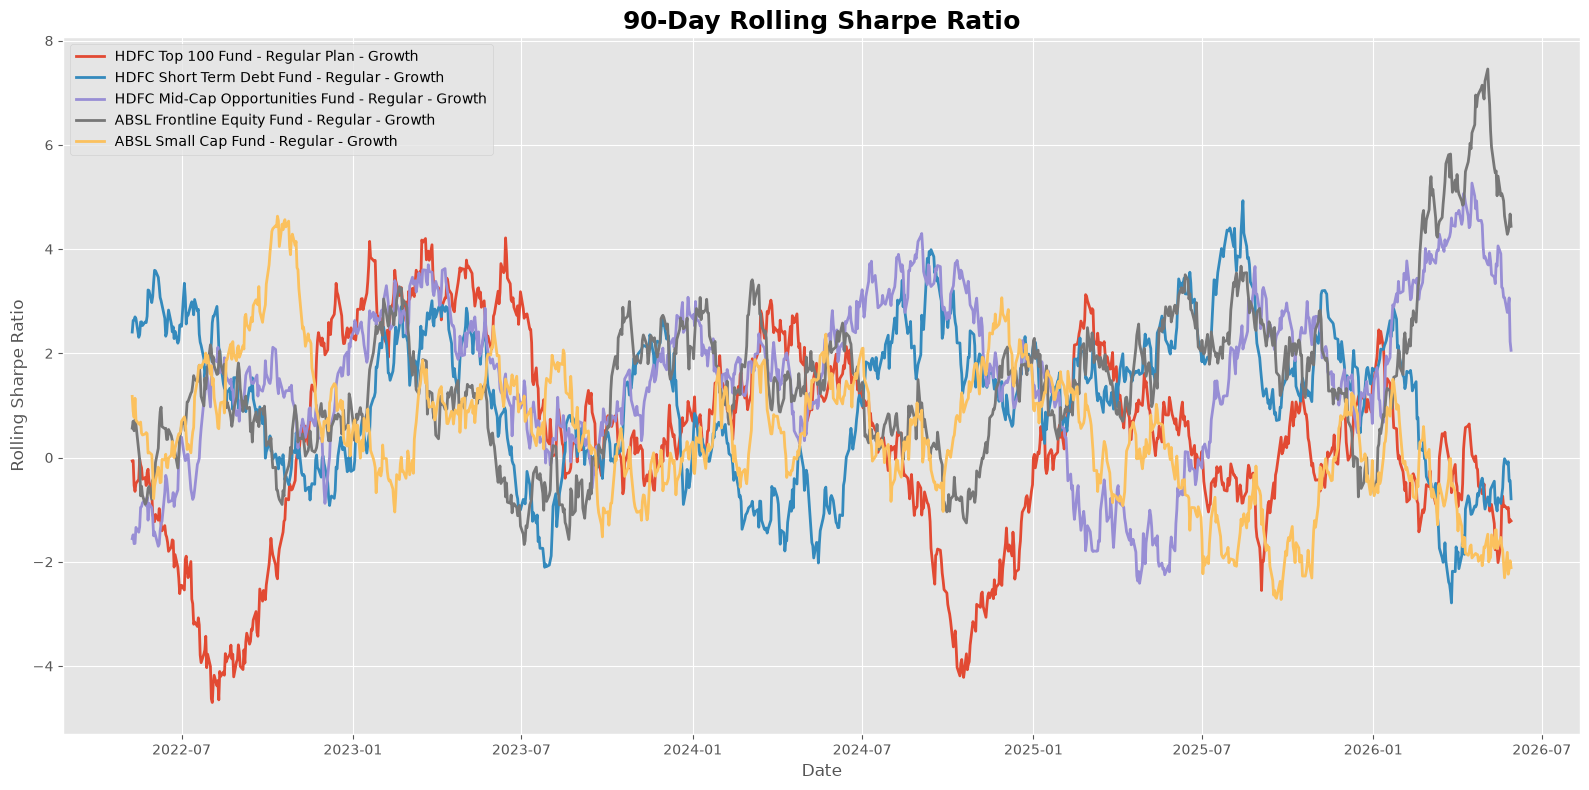

In [17]:
plt.figure(figsize=(16,8))

for fund in selected_funds:

    temp = rolling_df[
        rolling_df["amfi_code"] == fund
    ]

    plt.plot(
        temp["date"],
        temp["rolling_sharpe"],
        linewidth=2,
        label=temp["scheme_name"].iloc[0]
    )

plt.title(
    "90-Day Rolling Sharpe Ratio",
    fontsize=18,
    weight="bold"
)

plt.xlabel("Date")
plt.ylabel("Rolling Sharpe Ratio")

plt.legend()

plt.tight_layout()

plt.savefig(
    "../Charts/rolling_sharpe_chart.png",
    dpi=300
)

plt.show()

In [18]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


In [19]:
first_txn = (
    transactions
    .groupby("investor_id")["transaction_date"]
    .min()
    .reset_index()
)

first_txn["cohort_year"] = (
    first_txn["transaction_date"].dt.year
)

first_txn.head()

,investor_id,transaction_date,cohort_year
0,INV000001,2024-11-04,2024
1,INV000002,2024-03-29,2024
2,INV000003,2024-07-16,2024
3,INV000004,2024-03-16,2024
4,INV000005,2024-04-27,2024


In [20]:
transactions = transactions.merge(
    first_txn[
        ["investor_id", "cohort_year"]
    ],
    on="investor_id",
    how="left"
)

transactions.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
1,INV002952,2024-01-01,148567,Redemption,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
4,INV004691,2024-01-01,119094,Lumpsum,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending,2024


In [21]:
cohort = (
    transactions
    .groupby("cohort_year")
    .agg(
        average_sip_amount=("amount_inr", "mean"),
        total_invested=("amount_inr", "sum"),
        total_transactions=("investor_id", "count")
    )
    .reset_index()
)

cohort

,cohort_year,average_sip_amount,total_invested,total_transactions
0,2024,107422.541832,3491125187,32499
1,2025,109158.577061,30455243,279


In [22]:
pref = (
    transactions
    .groupby(
        ["cohort_year", "transaction_type"]
    )
    .size()
    .reset_index(name="count")
)

pref = (
    pref
    .sort_values(
        ["cohort_year", "count"],
        ascending=[True, False]
    )
    .drop_duplicates("cohort_year")
)

pref

,cohort_year,transaction_type,count
2,2024,SIP,19549
5,2025,SIP,167


In [23]:
cohort = cohort.merge(
    pref[
        [
            "cohort_year",
            "transaction_type"
        ]
    ],
    on="cohort_year"
)

cohort.rename(
    columns={
        "transaction_type": "preferred_transaction"
    },
    inplace=True
)

cohort

,cohort_year,average_sip_amount,total_invested,total_transactions,preferred_transaction
0,2024,107422.541832,3491125187,32499,SIP
1,2025,109158.577061,30455243,279,SIP


In [24]:
cohort.to_csv(
    "../Reports/cohort_analysis.csv",
    index=False
)

print("✅ cohort_analysis.csv saved successfully!")

✅ cohort_analysis.csv saved successfully!


In [25]:
# Only SIP transactions
sip = transactions[
    transactions["transaction_type"] == "SIP"
].copy()

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified,2024
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified,2024
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending,2024
5,INV001497,2024-01-01,101208,SIP,3295,Maharashtra,Mumbai,T30,36-45,Male,56.8,Mandate,Verified,2024
6,INV000786,2024-01-01,101208,SIP,15047,Madhya Pradesh,Bhopal,B30,26-35,Male,17.9,Mandate,Verified,2024


In [26]:
sip = sip.sort_values(
    ["investor_id", "transaction_date"]
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024


In [27]:
sip["gap_days"] = (
    sip.groupby("investor_id")["transaction_date"]
       .diff()
       .dt.days
)

sip.head()

,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status,cohort_year,gap_days
19621,INV000001,2024-11-04,120505,SIP,44856,Haryana,Gurugram,T30,36-45,Male,19.9,UPI,Verified,2024,NaN
24448,INV000001,2025-01-19,125497,SIP,3090,Haryana,Gurugram,T30,36-45,Male,19.9,Cheque,Pending,2024,76.0
5650,INV000002,2024-03-29,149322,SIP,2830,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,NaN
16803,INV000002,2024-09-21,120841,SIP,2354,Maharashtra,Pune,T30,46-55,Male,24.0,Mandate,Verified,2024,176.0
31881,INV000002,2025-05-17,119094,SIP,2690,Maharashtra,Pune,T30,46-55,Male,24.0,Cheque,Verified,2024,238.0


In [28]:
sip_summary = (
    sip.groupby("investor_id")
       .agg(
            sip_count=("transaction_date", "count"),
            average_gap_days=("gap_days", "mean")
       )
       .reset_index()
)

sip_summary.head()

,investor_id,sip_count,average_gap_days
0,INV000001,2,76.0
1,INV000002,3,207.0
2,INV000003,2,238.0
3,INV000004,6,85.4
4,INV000005,3,14.0


In [29]:
sip_summary = sip_summary[
    sip_summary["sip_count"] >= 6
]

sip_summary.head()

,investor_id,sip_count,average_gap_days
3,INV000004,6,85.400000
7,INV000008,6,70.400000
9,INV000010,6,64.800000
10,INV000011,7,40.166667
11,INV000012,8,57.000000


In [30]:
sip_summary["status"] = np.where(
    sip_summary["average_gap_days"] > 35,
    "At Risk",
    "Regular"
)

sip_summary.head()

,investor_id,sip_count,average_gap_days,status
3,INV000004,6,85.400000,At Risk
7,INV000008,6,70.400000,At Risk
9,INV000010,6,64.800000,At Risk
10,INV000011,7,40.166667,At Risk
11,INV000012,8,57.000000,At Risk


In [31]:
sip_summary.to_csv(
    "../Reports/sip_continuity.csv",
    index=False
)

print("✅ sip_continuity.csv saved successfully!")

✅ sip_continuity.csv saved successfully!


In [33]:
# Load Sharpe Ratio report
recommend = pd.read_csv("../Reports/sharpe_values.csv")

recommend.head()

,amfi_code,scheme_name,annual_return,annual_std,sharpe_ratio
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.025435,0.145481,-0.271960
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042987,0.039052,-0.563690
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.289279,0.189367,1.184359
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.226265,0.145682,1.106967
4,101207,ABSL Small Cap Fund - Regular - Growth,0.076502,0.257973,0.044584


In [34]:
# Create Risk Grade

recommend["risk_grade"] = np.where(
    recommend["annual_std"] < 0.10,
    "Low",
    np.where(
        recommend["annual_std"] < 0.20,
        "Moderate",
        "High"
    )
)

recommend.head()

,amfi_code,scheme_name,annual_return,annual_std,sharpe_ratio,risk_grade
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.025435,0.145481,-0.271960,Moderate
1,100025,HDFC Short Term Debt Fund - Regular - Growth,0.042987,0.039052,-0.563690,Low
2,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.289279,0.189367,1.184359,Moderate
3,101206,ABSL Frontline Equity Fund - Regular - Growth,0.226265,0.145682,1.106967,Moderate
4,101207,ABSL Small Cap Fund - Regular - Growth,0.076502,0.257973,0.044584,High


In [35]:
def recommend_funds(risk_appetite):

    results = (
        recommend[
            recommend["risk_grade"] == risk_appetite
        ]
        .sort_values(
            "sharpe_ratio",
            ascending=False
        )
        .head(3)
    )

    print("\nTop 3 Recommended Funds\n")

    print(
        results[
            [
                "scheme_name",
                "risk_grade",
                "sharpe_ratio",
                "annual_return"
            ]
        ]
    )

In [36]:
recommend_funds("Low")


Top 3 Recommended Funds

                                     scheme_name risk_grade  sharpe_ratio  \
27      ICICI Pru Liquid Fund - Regular - Growth        Low      0.962198   
31          Kotak Liquid Fund - Regular - Growth        Low      0.321465   
18  SBI Magnum Gilt Fund - Regular Plan - Growth        Low     -0.207392   

    annual_return  
27       0.069752  
31       0.066650  
18       0.056773  


In [37]:
recommend_funds("Moderate")


Top 3 Recommended Funds

                                      scheme_name risk_grade  sharpe_ratio  \
34  Mirae Asset Large Cap Fund - Regular - Growth   Moderate      1.637441   
30         Kotak Flexicap Fund - Regular - Growth   Moderate      1.458908   
36  Mirae Asset Tax Saver Fund - Regular - Growth   Moderate      1.367749   

    annual_return  
34       0.297414  
30       0.296776  
36       0.306736  


In [38]:
recommend_funds("High")


Top 3 Recommended Funds

                                       scheme_name risk_grade  sharpe_ratio  \
39           DSP Small Cap Fund - Regular - Growth       High      0.986164   
21      SBI Small Cap Fund - Regular Plan - Growth       High      0.979554   
11  Nippon India Small Cap Fund - Regular - Growth       High      0.366724   

    annual_return  
39       0.309965  
21       0.311266  
11       0.157567  


In [39]:
# Create a copy
sector = portfolio.copy()

# Convert percentage to decimal
sector["weight_decimal"] = sector["weight_pct"] / 100

sector.head()

,amfi_code,stock_symbol,stock_name,sector,weight_pct,market_value_cr,current_price_inr,portfolio_date,weight_decimal
0,119551,POWERGRID,Power Grid Corporation,Utilities,13.85,737.09,6011.08,2025-12-31,0.1385
1,119551,HDFCBANK,HDFC Bank Ltd,Banking,11.19,88.97,1074.65,2025-12-31,0.1119
2,119551,GRASIM,Grasim Industries Ltd,Diversified,9.90,208.45,5964.59,2025-12-31,0.0990
3,119551,DRREDDY,Dr. Reddy's Laboratories,Pharma,4.76,161.32,3748.82,2025-12-31,0.0476
4,119551,ASIANPAINT,Asian Paints Ltd,Paints,10.25,725.90,1321.45,2025-12-31,0.1025


In [40]:
sector_hhi = (
    sector
    .groupby("amfi_code")
    .apply(
        lambda x: np.sum(x["weight_decimal"] ** 2)
    )
    .reset_index(name="HHI")
)

sector_hhi.head()

,amfi_code,HHI
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [41]:
sector_hhi = sector_hhi.merge(
    funds[
        ["amfi_code", "scheme_name"]
    ],
    on="amfi_code",
    how="left"
)

sector_hhi = sector_hhi[
    [
        "amfi_code",
        "scheme_name",
        "HHI"
    ]
]

sector_hhi.head()

,amfi_code,scheme_name,HHI
0,100016,HDFC Top 100 Fund - Regular Plan - Growth,0.139534
1,100033,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.147592
2,101206,ABSL Frontline Equity Fund - Regular - Growth,0.129332
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709


In [42]:
sector_hhi = sector_hhi.sort_values(
    "HHI",
    ascending=False
)

sector_hhi.head(10)

,amfi_code,scheme_name,HHI
11,119092,Axis Bluechip Fund - Regular - Growth,0.206448
3,101207,ABSL Small Cap Fund - Regular - Growth,0.200700
18,119599,SBI Small Cap Fund - Direct Plan - Growth,0.174751
4,102885,UTI Nifty 50 Index Fund - Regular - Growth,0.174709
7,118632,Nippon India Large Cap Fund - Regular - Growth,0.168298
29,148568,Mirae Asset Emerging Bluechip Fund - Regular -...,0.167930
21,120505,ICICI Pru Midcap Fund - Regular - Growth,0.157570
22,120506,ICICI Pru Value Discovery Fund - Regular - Growth,0.153794
27,125498,HDFC Mid-Cap Opportunities Fund - Direct - Growth,0.152414
23,120841,Kotak Bluechip Fund - Regular - Growth,0.149680


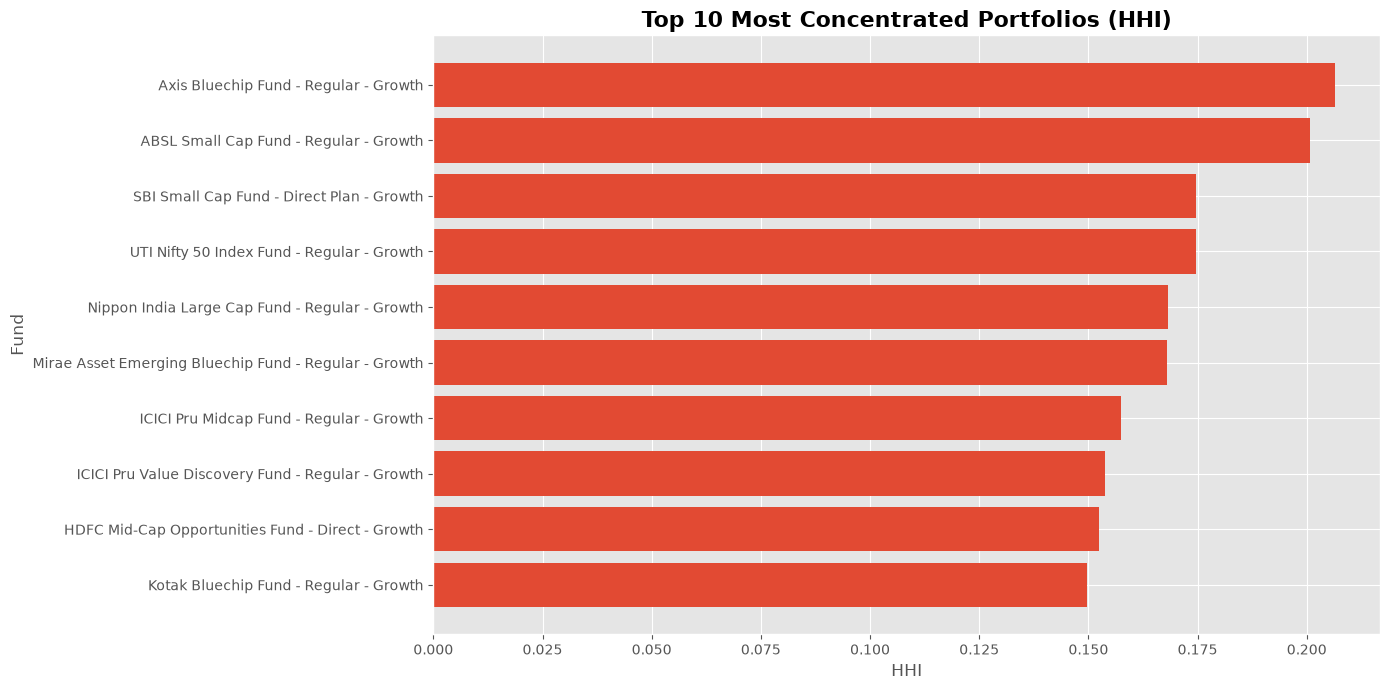

In [43]:
plt.figure(figsize=(14,7))

top10 = sector_hhi.head(10)

plt.barh(
    top10["scheme_name"],
    top10["HHI"]
)

plt.xlabel("HHI")
plt.ylabel("Fund")

plt.title(
    "Top 10 Most Concentrated Portfolios (HHI)",
    fontsize=16,
    weight="bold"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.savefig(
    "../Charts/sector_hhi_chart.png",
    dpi=300
)

plt.show()

In [44]:
sector_hhi.to_csv(
    "../Reports/sector_hhi.csv",
    index=False
)

print("✅ sector_hhi.csv saved successfully!")

✅ sector_hhi.csv saved successfully!


# Advanced Analytics Summary

## Key Insights

### 1. Value at Risk (VaR) Analysis
- Historical 95% VaR and CVaR were computed for all mutual funds.
- Funds with larger negative VaR values exhibit higher downside risk.
- CVaR highlighted the expected average loss during extreme market conditions.

---

### 2. Rolling Sharpe Ratio
- A 90-day rolling Sharpe Ratio was calculated for five selected mutual funds.
- The analysis revealed changing risk-adjusted performance over time.
- Funds with consistently higher Sharpe Ratios demonstrated more stable performance.

---

### 3. Investor Behaviour Analysis
- Investors were grouped into cohorts based on their first investment year.
- Average investment amount, total invested value, and preferred transaction type were analysed for each cohort.
- This analysis helps understand long-term investor behaviour and acquisition trends.

---

### 4. SIP Continuation Analysis
- Investors with six or more SIP transactions were analysed.
- The average gap between SIP transactions was calculated.
- Investors with an average gap greater than 35 days were flagged as **At Risk**, indicating possible SIP discontinuation.

---

### 5. Portfolio Concentration Analysis
- Sector concentration was measured using the Herfindahl-Hirschman Index (HHI).
- Funds with higher HHI values have more concentrated portfolios and potentially higher sector-specific risk.
- Diversified funds generally exhibited lower HHI values, indicating better risk distribution.